In [1]:
import numpy as np
import sys
import json
import math

In [2]:

a = 0b01101001
b = 0b01011001

n_bits = 8

def digit_list(a, n_bits):
    return np.array([int(i) for i in f'{a:0{n_bits}b}'])

def count1s(a, n_bits):
    return sum(digit_list(a, n_bits))

def inner_join(a, b, n_bits):
    inna = digit_list(a, n_bits)
    innb = digit_list(b, n_bits)
    return np.inner(inna, innb)

In [3]:
print(digit_list(a, 8))
print(digit_list(b, 8))

[0 1 1 0 1 0 0 1]
[0 1 0 1 1 0 0 1]


In [4]:
digs = 16

def make_1s_count(bin_digs):
    dig_arr = [0]*bin_digs
    for i in range(bin_digs):
        dig_arr[i] = sum(digit_list(i, bin_digs))
    return np.array(dig_arr)
    
make_1s_count(digs)

array([0, 1, 1, 2, 1, 2, 2, 3, 1, 2, 2, 3, 2, 3, 3, 4])

In [5]:
p = [[1, 2, 3],
     [0, 1, 0],
     [1, 1, 2]]
p = np.array(p)

dig = [0, 1, 2]
dig = np.array(dig)


In [6]:
sum(sum(p*dig))

14

***

In [13]:
import sys
sys.path.append('.')
sys.path.append('..')
sys.path.append('../../..')
sys.path

['/home/jacob/Dropbox/Dev/Python/quantum_projects/ts/ts_denoise/qiskit_qae',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python310.zip',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.10',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.10/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.10/site-packages',
 '.',
 '..',
 '../../..']

In [14]:
from utils.Target import *
from utils.Window import *
from utils.Callback import *
from utils.TS import *
from utils.Charts import *
from utils.Integrate import *
from utils.Circuits import *
from utils.Angles import *
from utils.Files import *
from utils.Cost import *
from utils.Metrics import *

from matplotlib import set_loglevel
set_loglevel("error")
%matplotlib inline

In [15]:
fname = 'beer_qiskit/training/beer_0n_n160_w8_ws4_z0.03_zr1_lat7_hist500.json'
try:
    f = open(f'{fname}', 'r')
except OSError:
    print(f'Could not open/read file: {fname}n')
    sys.exit()
with f:
    history = json.load(f)
    print(f'New history file was read')

New history file was read


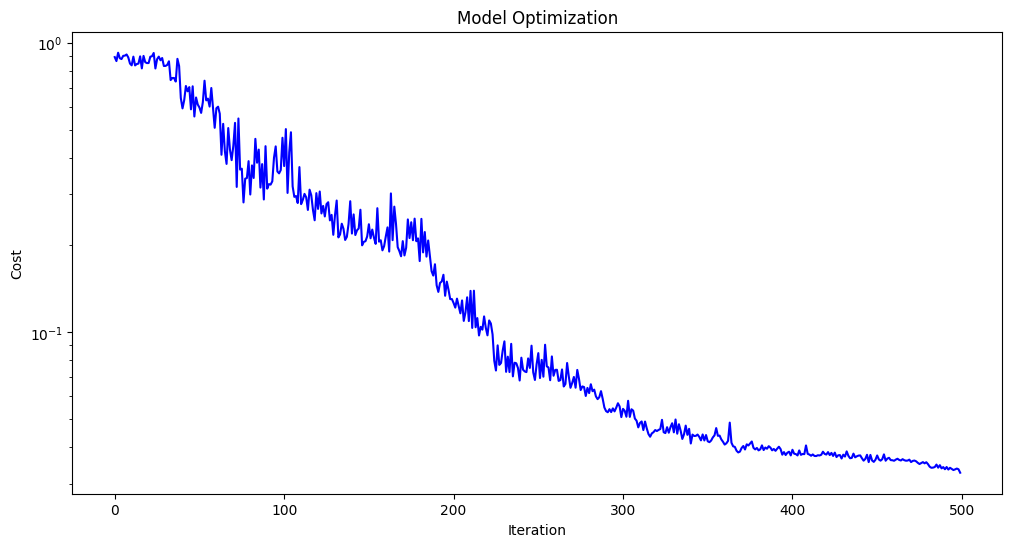

In [16]:
import matplotlib.pyplot as plt
# Plot deltas in the time series
plt.rcParams["figure.figsize"] = (12, 6)
plt.title(f"Model Optimization")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.yscale("log") # {'asinh', 'function', 'functionlog', 'linear', 'log', 'logit', 'symlog'}


plt.plot(range(len(history)), history, color='blue')
plt.show()

In [17]:
import numpy as np
mylist = [3, 6, 2, 9, 23, 7, 8, 11, 2, 6]
np.argmin(mylist)

2

In [18]:
import random
random.sample(range(0, 100), 5)

[49, 24, 95, 56, 16]

In [22]:
tmae = read_json_file('beer_qiskit/training/beer_0n_n160_w8_ws4_z0.03_zr1_lat7_hist500.json')
vmae = read_json_file('beer_qiskit/training/beer_0n_n160_w8_ws4_z0.03_zr1_lat5_hist500.json')
hist = read_json_file('beer_qiskit/training/beer_n160_w8_ws4_z0.03_zr1_lat5_hist500.json')

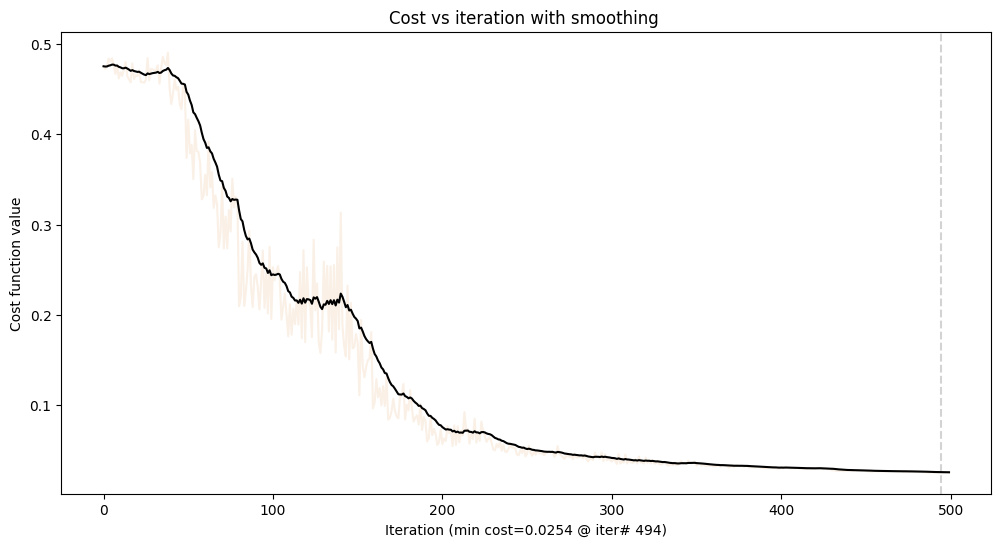

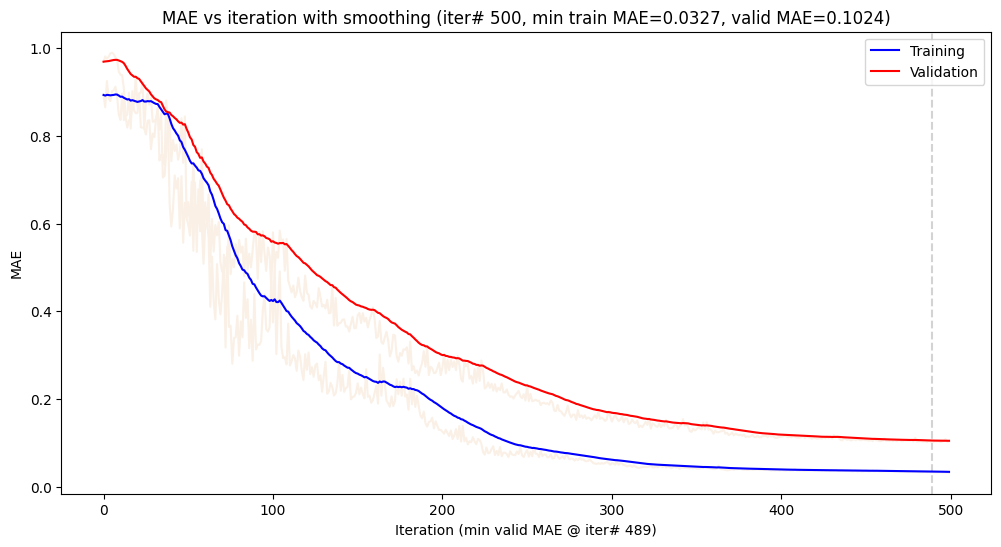

In [23]:
import warnings
warnings.filterwarnings("ignore")
# warnings.filterwarnings( "ignore", module = "matplotlib\..*" )

print()
cost_plot(hist, rcParams=(12, 6), smooth_weight=0.9, backplot=True)
print()
mae_plot(tmae, vmae, rcParams=(12, 6), smooth_weight=0.95, backplot=True)
print()

In [24]:

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle


def plot_colortable(colors, *, ncols=4, sort_colors=True):

    cell_width = 212
    cell_height = 22
    swatch_width = 48
    margin = 12

    # Sort colors by hue, saturation, value and name.
    if sort_colors is True:
        names = sorted(
            colors, key=lambda c: tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(c))))
    else:
        names = list(colors)

    n = len(names)
    nrows = math.ceil(n / ncols)

    width = cell_width * ncols + 2 * margin
    height = cell_height * nrows + 2 * margin
    dpi = 72

    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(margin/width, margin/height,
                        (width-margin)/width, (height-margin)/height)
    ax.set_xlim(0, cell_width * ncols)
    ax.set_ylim(cell_height * (nrows-0.5), -cell_height/2.)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.set_axis_off()

    for i, name in enumerate(names):
        row = i % nrows
        col = i // nrows
        y = row * cell_height

        swatch_start_x = cell_width * col
        text_pos_x = cell_width * col + swatch_width + 7

        ax.text(text_pos_x, y, name, fontsize=14,
                horizontalalignment='left',
                verticalalignment='center')

        ax.add_patch(
            Rectangle(xy=(swatch_start_x, y-9), width=swatch_width,
                      height=18, facecolor=colors[name], edgecolor='0.7')
        )

    return fig

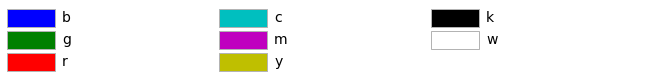

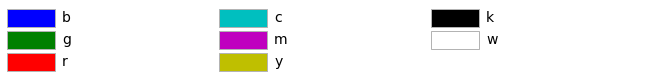

In [25]:
plot_colortable(mcolors.BASE_COLORS, ncols=3, sort_colors=False)

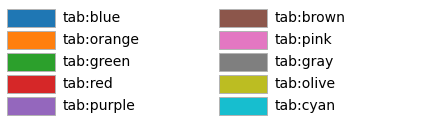

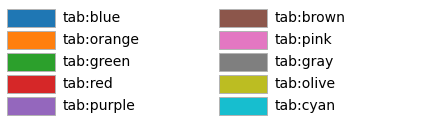

In [26]:
plot_colortable(mcolors.TABLEAU_COLORS, ncols=2, sort_colors=False)

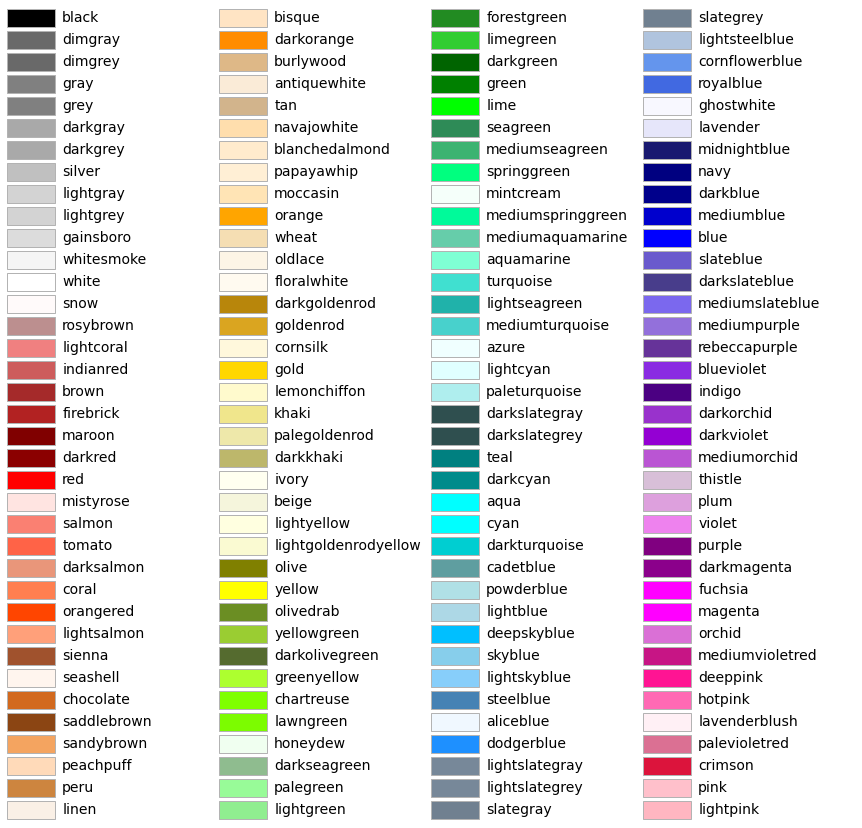

In [27]:
plot_colortable(mcolors.CSS4_COLORS)
plt.show()

In [28]:
import datetime
secs = 10553.49
str(datetime.timedelta(seconds=int(secs)))

'2:55:53'

***

In [1]:
import sys
sys.path.append('.')
sys.path.append('..')
sys.path.append('../../..')
sys.path

['/home/jacob/Dropbox/Dev/Python/quantum_projects/ts/ts_denoise/qiskit_qae',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python310.zip',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.10',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.10/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.10/site-packages',
 '.',
 '..',
 '../../..']

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pylab
import math
from IPython.display import clear_output

from utils.Target import *
from utils.Window import *
from utils.Callback import *
from utils.TS import *
from utils.Charts import *
from utils.Integrate import *
from utils.Circuits import *
from utils.Angles import *
from utils.Files import *
from utils.Cost import *
from utils.Metrics import *

from matplotlib import set_loglevel
set_loglevel("error")
%matplotlib inline

In [30]:
probs = np.array([[0.99999, 0.99999, 0.99999, 0.99999], [0.99999, 0.99999, 0.99999, 0.99999]])
(np.round(cost_zero(probs), 6), np.round(cost_zero_log(probs), 6))

(1e-05, 1e-05)

In [31]:
probs = np.array([[0.0001, 0.0001, 0.0001, 0.0001], [0.0001, 0.0001, 0.0001, 0.0001]])
(np.round(cost_zero(probs), 6), np.round(cost_zero_log(probs), 6))

(0.9999, -0.0001)

In [32]:
probs = np.array([[0.99, 0.98, 0.89, 0.999], [0.95, 0.97, 0.88, 0.9]])
(cost_zero(probs), cost_zero_log(probs))

(0.030000000000000027, 0.030671815120526014)

In [33]:
probs = np.array([[0.1, 0.3, 0.7], [0.2, 0.2, 0.6]])
(cost_zero(probs), cost_zero_log(probs))

(0.85, 1.9560115027140728)

In [34]:
probs = np.array([[0.001, 0.01, 0.002], [0.0001, 0.003, 0.9]])
(cost_zero(probs), cost_zero_log(probs))

(0.99945, 3.4538276394910685)

In [35]:
probs = np.array([[0.000001, 0, 0.002], [0.0001, 0.003, 0.9]])
(cost_zero(probs), cost_zero_log(probs))

(0.9999495, -0.0001)

In [36]:
[print(f'{x:<10}\t{np.log(x)}') for x in [1e-10, 0.000001, 0.0001, 0.001, 0.01, 0.1, 0.5, 0.999, 0.9990001]]

1e-10     	-23.025850929940457
1e-06     	-13.815510557964274
0.0001    	-9.210340371976182
0.001     	-6.907755278982137
0.01      	-4.605170185988091
0.1       	-2.3025850929940455
0.5       	-0.6931471805599453
0.999     	-0.0010005003335835344
0.9990001 	-0.001000400233488497


[None, None, None, None, None, None, None, None, None]

In [37]:
import torch
import torch.nn as nn

loss = nn.KLDivLoss(size_average=None, reduce=None, reduction='mean', log_target=False)
# input1 = torch.randn(4, 6, requires_grad=True)
# input2 = torch.randn(4, 6, requires_grad=True)
input1 = torch.FloatTensor([0.99, 0.001, 0.005, 0.004, 0.001])
input2 = torch.FloatTensor([0.01, 0.5, 0.6, 0.004, 0.99])
output = loss(input1, input2)

print('output: ', output) #output:  tensor(0.0591, grad_fn=)

output:  tensor(-0.1491)


---

In [125]:
import numpy as np

probs1 = [0.1, 0.05, 0.05, 0.3, 0.2, 0.1, 0.2, 0.0]
probs2 = [0.01, 0.02, 0.3, 0, 0.03, 0, 0.1, 0, 0.04, 0, 0.05, 0.05, 0.1, 0.2, 0.02, 0.08]

### Takes a list of probabilities (add to 1) and presents them in tabular form
def report_c2p(probs):
    qubit_no = int(np.log2(len(probs)))
    qa = np.array([[int(bit) for bit in format(qn, f'#0{qubit_no+2}b')[2:]] for qn in range(len(probs))])
    qr = np.zeros((qa.shape[0],qa.shape[1]+1))
    qr[:,:-1] = qa
    qr[:,qa.shape[1]:qa.shape[1]+1] = np.array([probs]).transpose()
    return qr

### Converts results of circuit state_vector measurements to 
### individual qubit measurements
#   probs: a list of circuit measurement probabilities (must be of length 2^n)
#   returns: all qubit Z projective measurements onto |0>
def cprobs_to_qprobs(probs):
    qubit_no = int(np.log2(len(probs)))
    qpos = [[int(bit) for bit in format(qn, f'#0{qubit_no+2}b')[2:]] for qn in range(len(probs))]
    # qarr = np.array(qpos)
    qprobs = np.zeros(qubit_no)
    for qp in range(len(qpos)):
        for q in range(qubit_no):
            qprobs[q] += qpos[qp][q]*probs[qp]
    return qprobs

res = cprobs_to_qprobs(probs2)
print('Result of mapping a circuit state to\nindividual qubit states:\n\n\t', res, '\n')

report_c2p(probs2)

Result of mapping a circuit state to
individual qubit states:

	 [0.54 0.53 0.6  0.35] 



array([[0.  , 0.  , 0.  , 0.  , 0.01],
       [0.  , 0.  , 0.  , 1.  , 0.02],
       [0.  , 0.  , 1.  , 0.  , 0.3 ],
       [0.  , 0.  , 1.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.03],
       [0.  , 1.  , 0.  , 1.  , 0.  ],
       [0.  , 1.  , 1.  , 0.  , 0.1 ],
       [0.  , 1.  , 1.  , 1.  , 0.  ],
       [1.  , 0.  , 0.  , 0.  , 0.04],
       [1.  , 0.  , 0.  , 1.  , 0.  ],
       [1.  , 0.  , 1.  , 0.  , 0.05],
       [1.  , 0.  , 1.  , 1.  , 0.05],
       [1.  , 1.  , 0.  , 0.  , 0.1 ],
       [1.  , 1.  , 0.  , 1.  , 0.2 ],
       [1.  , 1.  , 1.  , 0.  , 0.02],
       [1.  , 1.  , 1.  , 1.  , 0.08]])

***

In [128]:
### Test state vector simulation

from qiskit import QuantumRegister, QuantumCircuit, Aer
from qiskit.quantum_info import Statevector
import numpy as np

backend = Aer.get_backend('statevector_simulator')

q = QuantumRegister(1)

qc = QuantumCircuit(q)

qc.u(np.pi/4,np.pi/4,np.pi/4, q)

qc.draw()

┌────────────────┐
q2: ┤ U(π/4,π/4,π/4) ├
    └────────────────┘

In [129]:
outputstate = backend.run(qc, shots=1).result().get_statevector()
probs = Statevector(outputstate).probabilities()
print(probs)

[0.85355339 0.14644661]


In [130]:
outputstate = backend.run(qc, shots=10000).result().get_statevector()
probs = Statevector(outputstate).probabilities()
print(probs)

[0.85355339 0.14644661]


In [132]:
keep_encoder=False
train_qae_qc, in_params, enc_params, dec_params, all_weight_params = \
    train_xyz_qae(8, 1, reps=2, ent='linear', 
                  in_seq_label='N', in_seq_name='Noisy Input', 
                  out_seq_label='P', out_seq_name='Pure Output',
                  keep_encoder=keep_encoder)

noisy_in_params = in_params[:len(in_params)//2]
pure_out_params = in_params[len(in_params)//2:]
train_qae_qc = train_qae_qc.decompose()

p_list = []

p_no = 0
for p in in_params:
    p_list.append(np.pi /4 + 1/100*p_no)
    p_no += 1

init_pt = range(len(all_weight_params))
p_no = 0
for p in all_weight_params[:len(all_weight_params)//2]:
    p_list.append(init_pt[p_no])
    p_no += 1
for p in all_weight_params[len(all_weight_params)//2:]:
    p_list.append(-init_pt[p_no])
    p_no += 1

qc=train_qae_qc
initial_point = np.random.random(len(all_weight_params))

# outputstate = backend.run(qc, shots=1).result().get_statevector()

In [133]:
p_list

[0.7853981633974483,
 0.7953981633974483,
 0.8053981633974483,
 0.8153981633974483,
 0.8253981633974483,
 0.8353981633974483,
 0.8453981633974483,
 0.8553981633974483,
 0.8653981633974482,
 0.8753981633974482,
 0.8853981633974483,
 0.8953981633974483,
 0.9053981633974483,
 0.9153981633974483,
 0.9253981633974483,
 0.9353981633974483,
 0.9453981633974483,
 0.9553981633974483,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 -54,
 -55,
 -56,
 -57,
 -58,
 -59,
 -60,
 -61,
 -62,
 -63,
 -64,
 -65,
 -66,
 -67,
 -68,
 -69,
 -70,
 -71,
 -72,
 -73,
 -74,
 -75,
 -76,
 -77,
 -78,
 -79,
 -80,
 -81,
 -82,
 -83,
 -84,
 -85,
 -86,
 -87,
 -88,
 -89,
 -90,
 -91,
 -92,
 -93,
 -94,
 -95,
 -96,
 -97,
 -98,
 -99,
 -100,
 -101,
 -102,
 -103,
 -104,
 -105,
 -106,
 -107]